### Code Review Agent

In [1]:
print("Ok")

Ok


In [2]:
from typing import TypedDict

from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph, START, END

In [3]:
load_dotenv()

True

In [4]:
primary_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

fallback_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [5]:
# llm fallback
llm = primary_llm.with_fallbacks(
    [fallback_llm]
)

In [6]:
# define state
class CodeReviewState(TypedDict):

    pr_url: str   

    pr_title: str
    pr_description: str

    changed_files: list
    code_diff: str

    code_analysis: str

    bugs: str
    security_issues: str
    quality_issues: str

    final_review: str

In [7]:
def fetch_pr(state: CodeReviewState) -> CodeReviewState:

    # For now we are using dummy PR data.
    # Later we will replace this with GitHub API.

    return {
        "pr_title": "Fix user login",
        
        "pr_description": """
        Thi hentication system.
        """,

        "changed_files": [
            "auth.py",
            "database.py"
        ],

        "code_diff": """
        def login(username, password):

            query = f"SELECT * FROM users WHERE username='{username}'"

            user = database.execute(query)

            if user:
                return True

            return False
        """
    }

In [8]:
def analyze_code(state: CodeReviewState) -> CodeReviewState:

    prompt = f"""
You are a senior software engineer.

Analyze this GitHub Pull Request.

PR TITLE:
{state["pr_title"]}

PR DESCRIPTION:
{state["pr_description"]}

CHANGED FILES:
{state["changed_files"]}

CODE DIFF:
{state["code_diff"]}

Analyze:

1. What the code does
2. Important functions
3. Potential bugs
4. Security concerns
5. Code quality concerns
6. Important edge cases
"""

    response = llm.invoke(prompt)

    return {
        "code_analysis": response.content
    }

In [9]:
def bug_detector(state: CodeReviewState) -> CodeReviewState:

    prompt = f"""
You are a senior bug detection engineer.

Find bugs in the following Pull Request.

CODE:
{state["code_diff"]}

CODE ANALYSIS:
{state["code_analysis"]}

Look for:

- Logic errors
- Runtime errors
- Incorrect conditions
- Edge cases
- Exception handling problems
- Data handling problems

For every bug provide:

Severity:
File:
Issue:
Explanation:
Suggested Fix:

If there are no bugs, say:

No bugs found.
"""

    response = llm.invoke(prompt)

    return {
        "bugs": response.content
    }


In [10]:
def security_checker(state: CodeReviewState) -> CodeReviewState:

    prompt = f"""
You are an expert cybersecurity engineer.

Analyze this Pull Request for security vulnerabilities.

CODE:
{state["code_diff"]}

Check for:

- SQL Injection
- Command Injection
- Authentication vulnerabilities
- Authorization vulnerabilities
- Hardcoded secrets
- Sensitive information exposure
- Unsafe input handling
- Path traversal
- XSS
- Insecure dependencies
- Weak cryptography

For every issue provide:

Severity:
File:
Vulnerability:
Explanation:
Suggested Fix:

If there are no security problems, say:

No security issues found.
"""

    response = llm.invoke(prompt)

    return {
        "security_issues": response.content
    }

In [11]:
def quality_checker(state: CodeReviewState) -> CodeReviewState:

    prompt = f"""
You are a senior software architect.

Review the following code for quality.

CODE:
{state["code_diff"]}

Check:

- Readability
- Maintainability
- Naming
- Code duplication
- SOLID principles
- Error handling
- Performance
- Python best practices

Return:

Issue:
Explanation:
Recommendation:

If the code quality is good, say:

No major quality issues found.
"""

    response = llm.invoke(prompt)

    return {
        "quality_issues": response.content
    }


In [12]:
def aggregate_findings(state: CodeReviewState) -> CodeReviewState:

    prompt = f"""
You are a lead software engineer.

Create a consolidated code review.

BUGS:
{state["bugs"]}

SECURITY ISSUES:
{state["security_issues"]}

QUALITY ISSUES:
{state["quality_issues"]}

Organize all findings into:

CRITICAL
HIGH
MEDIUM
LOW

Remove duplicate findings.

Prioritize security vulnerabilities.

Do not invent issues that were not identified.
"""

    response = llm.invoke(prompt)

    return {
        "final_review": response.content
    }


In [13]:
def generate_report(state: CodeReviewState) -> CodeReviewState:

    prompt = f"""
Create a professional GitHub Pull Request review.

PR TITLE:
{state["pr_title"]}

CONSOLIDATED FINDINGS:
{state["final_review"]}

Use this format:

# Code Review

## Summary

## Critical Issues

## Bugs

## Security Issues

## Code Quality

## Recommended Changes

## Overall Verdict

Choose one:

APPROVE
REQUEST CHANGES
NEEDS DISCUSSION
"""

    response = llm.invoke(prompt)

    return {
        "final_review": response.content
    }

In [14]:
graph = StateGraph(CodeReviewState)

# adding nodes
graph.add_node("fetch_pr", fetch_pr)

graph.add_node("analyze_code", analyze_code)

graph.add_node("bug_detector", bug_detector)

graph.add_node("security_checker", security_checker)

graph.add_node("quality_checker", quality_checker)

graph.add_node("aggregate_findings", aggregate_findings)

graph.add_node("generate_report", generate_report)

# adding edges
graph.add_edge(START, "fetch_pr")

graph.add_edge(
    "fetch_pr",
    "analyze_code"
)

graph.add_edge(
    "analyze_code",
    "bug_detector"
)

graph.add_edge(
    "analyze_code",
    "security_checker"
)

graph.add_edge(
    "analyze_code",
    "quality_checker"
)

graph.add_edge(
    "bug_detector",
    "aggregate_findings"
)

graph.add_edge(
    "security_checker",
    "aggregate_findings"
)

graph.add_edge(
    "quality_checker",
    "aggregate_findings"
)

graph.add_edge(
    "aggregate_findings",
    "generate_report"
)

graph.add_edge(
    "generate_report",
    END
)


workflow = graph.compile()

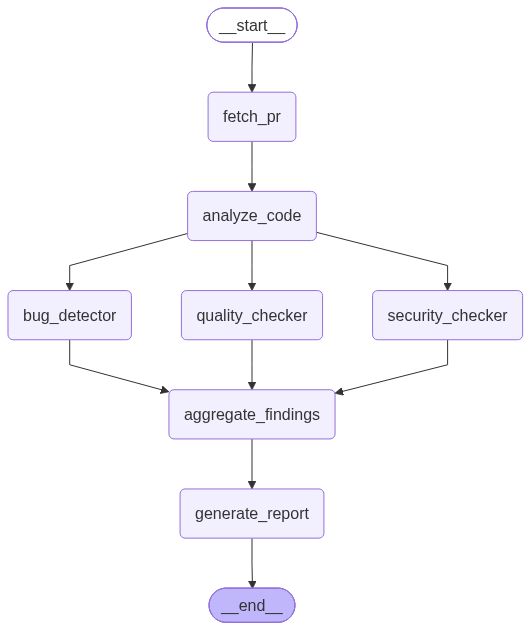

In [15]:
workflow

In [16]:
initial_state = {

    "pr_url":
        "https://github.com/syedTalha1076/Youtube-Summarizer-Agent",

    "pr_title": "",

    "pr_description": "",

    "changed_files": [],

    "code_diff": "",

    "code_analysis": "",

    "bugs": "",

    "security_issues": "",

    "quality_issues": "",

    "final_review": ""
}


In [17]:
result = workflow.invoke(initial_state)

In [18]:
print("\n")
print("=" * 70)
print("FINAL CODE REVIEW")
print("=" * 70)
print()

print(result["final_review"])



FINAL CODE REVIEW

# Code Review

## Summary
The PR titled **“Fix user login”** attempts to address login functionality in `login.py`. While the intent is good, the current implementation contains several severe security and reliability problems that would allow unauthenticated access, expose the application to SQL‑injection, and make the service unstable under error conditions. These issues must be resolved before the code can be merged.

---

## Critical Issues
| # | Issue | Impact | Recommended Fix |
|---|-------|--------|-----------------|
| C1 | **Password is never verified** – the function only checks that a username exists. | Complete authentication bypass; any caller can log in with a valid username and any password. | Retrieve the stored password hash for the supplied username and verify the supplied password using a constant‑time algorithm (`bcrypt.checkpw`, `argon2.verify`, etc.). Return success **only** when the hash matches. |
| C2 | **SQL‑Injection via raw f‑string** – 